In [8]:
!pip install torch yfinance numpy matplotlib arch pandas


In [9]:
#The setup
import yfinance as yf
from arch import arch_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

stock_choice = "AAPL"

data = yf.download(
    stock_choice,
    start="2000-01-01",
    end="2021-12-31",
    interval="1d",
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [10]:
#train regime

#GARCH
scaling_factor = 100 #the model gave a low number error
prices = data["Close"]
returns = np.log(prices).diff().dropna()

train_returns = returns["2000-01-01":"2017-12-31"]
val_returns  = returns["2018-01-01":"2018-12-31"]
print(len(val_returns))

model = arch_model(train_returns * scaling_factor, vol="Garch", p=1, q=1)
res = model.fit()
#print(res.summary())


251
Iteration:      1,   Func. Count:      6,   Neg. LLF: 28215.34535876598
Iteration:      2,   Func. Count:     15,   Neg. LLF: 4049177.948618684
Iteration:      3,   Func. Count:     22,   Neg. LLF: 10143.658547782612
Iteration:      4,   Func. Count:     28,   Neg. LLF: 15865.873502030694
Iteration:      5,   Func. Count:     34,   Neg. LLF: 10070.384251291947
Iteration:      6,   Func. Count:     39,   Neg. LLF: 10337.987766399372
Iteration:      7,   Func. Count:     46,   Neg. LLF: 11051.544077343056
Iteration:      8,   Func. Count:     54,   Neg. LLF: 10069.920066632767
Iteration:      9,   Func. Count:     59,   Neg. LLF: 10069.862477567756
Iteration:     10,   Func. Count:     64,   Neg. LLF: 10069.861584638209
Iteration:     11,   Func. Count:     69,   Neg. LLF: 10069.861580674282
Iteration:     12,   Func. Count:     73,   Neg. LLF: 10069.861580675439
Optimization terminated successfully    (Exit mode 0)
            Current function value: 10069.861580674282
            I

In [11]:
#validation regime
horizon = 20

#GARCH
garch_preds = []
targets = []

history = train_returns.copy() * scaling_factor

for t in range(len(val_returns) - horizon):

    #GARCH Refit
    model = arch_model(history, p=1, q=1)
    res = model.fit(disp="off")
    forecast = res.forecast(horizon=horizon)
    var_forecast = forecast.variance.values[-1]
    garch_vol = np.sqrt(np.mean(var_forecast)) / scaling_factor
    garch_preds.append(garch_vol)

    #Ground Truth
    future = val_returns.iloc[t:t+horizon]
    realized_vol = np.std(future.values)
    targets.append(realized_vol)

    #new history
    history = pd.concat([history, val_returns.iloc[t:t+1]*scaling_factor])


GARCH MSE: 4.564495532019241e-05


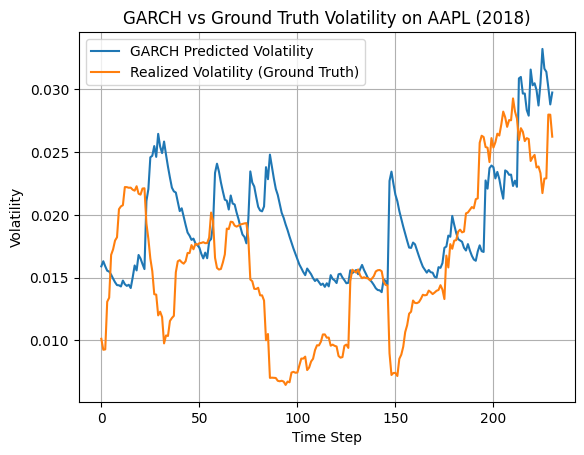

In [12]:
#MSE error

garch_pred_np = np.array(garch_preds)
targets_np = np.array(targets)
GARCH_MSE = np.mean((garch_pred_np - targets_np)**2)
print("GARCH MSE:", GARCH_MSE)
#print(len(garch_pred_np))

plt.plot(garch_preds, label="GARCH Predicted Volatility")
plt.plot(targets, label="Realized Volatility (Ground Truth)")

plt.title("GARCH vs Ground Truth Volatility on AAPL (2018)")
plt.xlabel("Time Step")
plt.ylabel("Volatility")

plt.legend()
plt.grid(True)

In [ ]:
#GARCH but with 10 or 60 day lookbacks
#GARCH but with 10 or 60 day lookbacks
'''
I want a function that takes a range of prices, takes a year, and outputs a
graph of GARCH vs target volatility. The special thing is that the GARCH
should be contrainsted to certain lookbehind date (which is another passable param)

The volatility will be a 20 day future forecast and I'll want it for every day in
the year parameter. It will work for one ticker at a time
'''
def plot_garch_vs_target(price_series,
                         lookback,
                         year='2018',
                         horizon=20,
                         history_start=None,
                         scaling_factor=100.0,
                         fit_disp='off'):

    #convert prices
    returns = np.log(price_series).diff().dropna().sort_index()
    if history_start is not None:
        returns = returns.loc[history_start:]

    target_idx = returns.loc[f'{year}-01-01':f'{year}-12-31'].index
    dates = []
    preds = []
    targets = []

    for date in target_idx:
        pos = returns.index.get_loc(date)
        #check history and future
        if pos < lookback:
            continue
        if pos + horizon > len(returns):
            continue
        hist = returns.iloc[pos - lookback: pos].values.astype(float)
        fut  = returns.iloc[pos: pos + horizon].values.astype(float)
        target = float(np.std(fut))

        pred = np.nan
        model = arch_model(hist * scaling_factor, vol='Garch', p=1, q=1)
        res = model.fit(disp=fit_disp)
        fc = res.forecast(horizon=horizon)
        var_forecast = fc.variance.values[-1]
        pred = float(np.sqrt(np.mean(var_forecast)) / scaling_factor)

        dates.append(pd.to_datetime(date))
        preds.append(pred)
        targets.append(target)

    dates = np.array(dates, dtype='datetime64[ms]')
    preds = np.array(preds, dtype=np.float32)
    targets = np.array(targets, dtype=np.float32)

    valid = ~np.isnan(preds)
    mse = np.mean((preds[valid] - targets[valid])**2) if valid.any() else np.nan
    print(f'lookback={lookback}  year={year}  horizon={horizon}  days={valid.sum()}  MSE={mse:.6e}')

    #time-series plot
    plt.figure(figsize=(12,4))
    if valid.any():
        plt.plot(dates[valid], preds[valid], label='GARCH pred', alpha=0.8)
        plt.plot(dates[valid], targets[valid], label='Realized (target)', alpha=0.9)
    else:
        plt.plot(dates, targets, label='Realized (target)', alpha=0.9)
    plt.title(f'GARCH vs Realized on AAPL: lookback={lookback} ({year})')
    plt.xlabel('Date'); plt.ylabel('Volatility'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    #return arrays
    return dates, preds, targets



[*********************100%***********************]  1 of 1 completed


lookback=10  year=2018  horizon=20  days=251  MSE=1.095228e-04


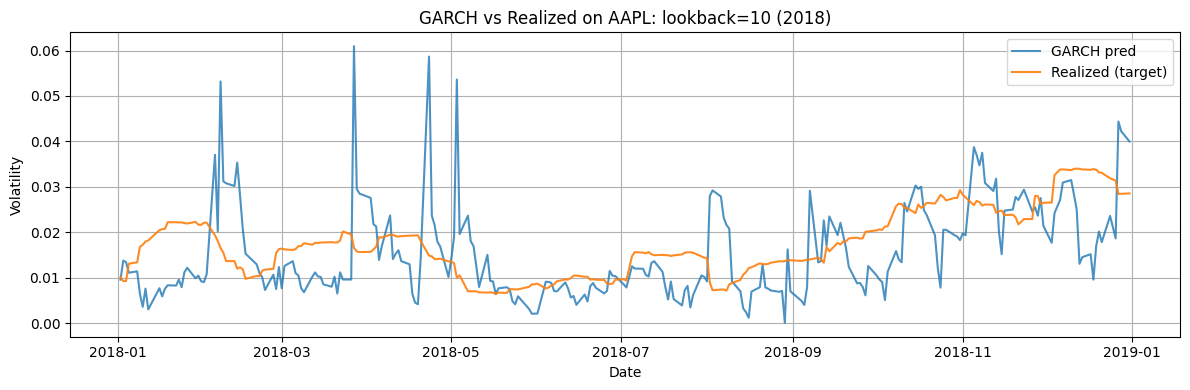

In [28]:
#Garch on 10/60 lookbacks tester

tickers = ['AAPL']
data = yf.download(
    tickers,
    start="2000-01-01",
    end="2021-12-31",
    interval="1d",
    auto_adjust=True
)

price_series = data["Close"]   # or prices variable you already have
dates, preds, targets = plot_garch_vs_target(price_series, lookback=10, year='2018', horizon=20, history_start='2017-01-01')

lookback=60  year=2018  horizon=20  days=251  MSE=5.120445e-05


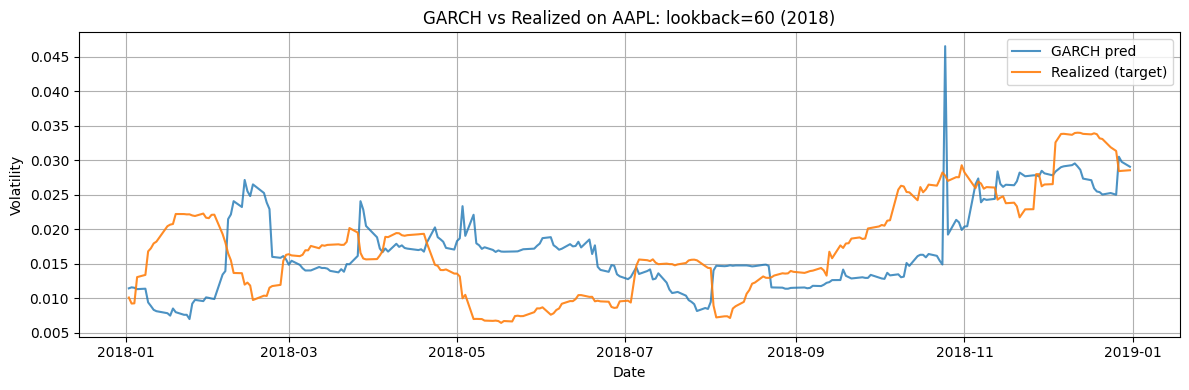

In [29]:
dates60, preds60, targets60 = plot_garch_vs_target(price_series, lookback=60, year='2018', horizon=20, history_start='2017-01-01')


In [15]:
#Deep Model Data Set-up